<a href="https://colab.research.google.com/github/komazawa-deep-learning/komazawa-deep-learning.github.io/blob/master/2026notebooks/2026_0417psy3a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2026年度駒澤大学文学部心理学科 心理学特講ⅢA 第 1 回：導入実習

## 本日の目標
1. Google Colaboratoryの基本操作に慣れる
2. 反応時間データの可視化を体験する
3. 「入力→処理→出力」の枠組みで課題を考える

## 1. 環境のセットアップ

必要なライブラリをインポートします。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

# 日本語表示の設定（Google Colabの場合）
!pip install japanize-matplotlib -q
import japanize_matplotlib

# プロット設定
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✓ ライブラリのインポートが完了しました")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 20.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✓ ライブラリのインポートが完了しました


## 2. 架空の反応時間データを生成

簡単な課題のデータを生成します。
- **条件A**: 単純刺激（○が出たらボタンを押す）
- **条件B**: 選択反応（○なら左、△なら右ボタン）

In [2]:
# シード固定（再現性のため）
np.random.seed(42)

# 条件Aのデータ生成（単純反応）
n_trials_A = 50
mean_rt_A = 300  # 平均300ms
std_rt_A = 50    # 標準偏差50ms
rt_condition_A = np.random.normal(mean_rt_A, std_rt_A, n_trials_A)

# 条件Bのデータ生成（選択反応）
n_trials_B = 50
mean_rt_B = 450  # 平均450ms（選択が必要なので遅い）
std_rt_B = 80    # 標準偏差80ms（ばらつきも大きい）
rt_condition_B = np.random.normal(mean_rt_B, std_rt_B, n_trials_B)

# 負の値を除去（反応時間は正の値のみ）
rt_condition_A = rt_condition_A[rt_condition_A > 0]
rt_condition_B = rt_condition_B[rt_condition_B > 0]

print(f"条件A（単純反応）: {len(rt_condition_A)} 試行")
print(f"条件B（選択反応）: {len(rt_condition_B)} 試行")

条件A（単純反応）: 50 試行
条件B（選択反応）: 50 試行


## 3. データの基本統計量

平均値だけでなく、ばらつき（標準偏差）も重要です。

In [3]:
# 基本統計量を計算
stats_A = {
    '平均': np.mean(rt_condition_A),
    '中央値': np.median(rt_condition_A),
    '標準偏差': np.std(rt_condition_A, ddof=1),
    '最小値': np.min(rt_condition_A),
    '最大値': np.max(rt_condition_A)
}

stats_B = {
    '平均': np.mean(rt_condition_B),
    '中央値': np.median(rt_condition_B),
    '標準偏差': np.std(rt_condition_B, ddof=1),
    '最小値': np.min(rt_condition_B),
    '最大値': np.max(rt_condition_B)
}

# DataFrameとして表示
df_stats = pd.DataFrame({
    '条件A（単純反応）': stats_A,
    '条件B（選択反応）': stats_B
})

print("=== 基本統計量 ===")
print(df_stats.round(2))

=== 基本統計量 ===
      条件A（単純反応）  条件B（選択反応）
平均       288.73     451.42
中央値      288.29     453.69
標準偏差      46.68      69.95
最小値      202.02     240.42
最大値      392.61     575.17


## 4. データの可視化（ヒストグラム）

分布の形状を見ることで、平均値だけでは分からない情報が得られます。

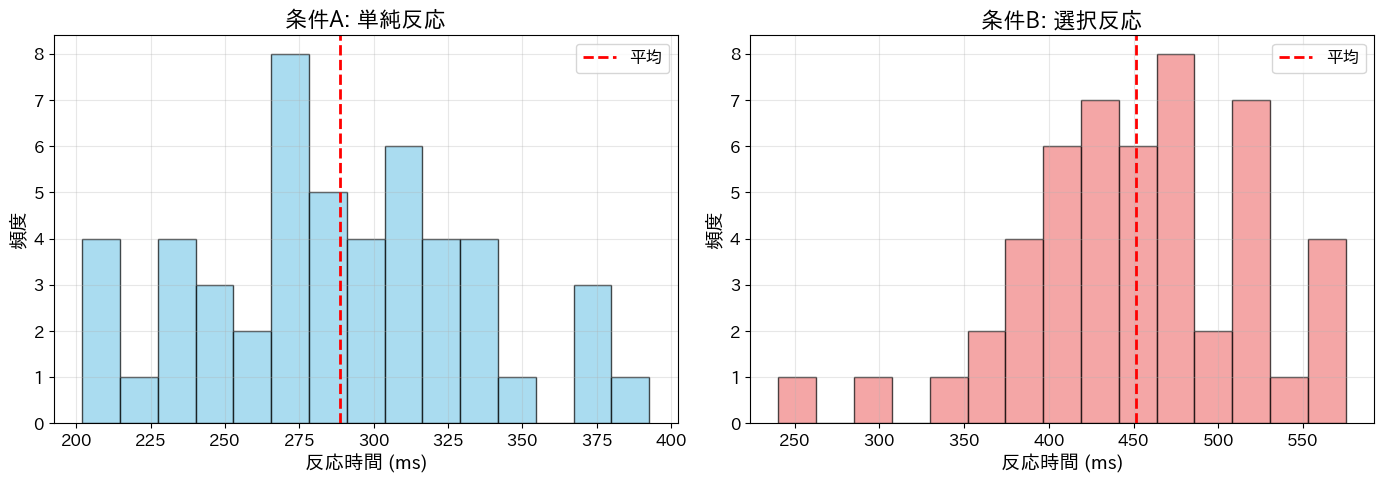

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 条件Aのヒストグラム
axes[0].hist(rt_condition_A, bins=15, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].axvline(np.mean(rt_condition_A), color='red', linestyle='--', linewidth=2, label='平均')
axes[0].set_xlabel('反応時間 (ms)', fontsize=14)
axes[0].set_ylabel('頻度', fontsize=14)
axes[0].set_title('条件A: 単純反応', fontsize=16, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(alpha=0.3)

# 条件Bのヒストグラム
axes[1].hist(rt_condition_B, bins=15, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1].axvline(np.mean(rt_condition_B), color='red', linestyle='--', linewidth=2, label='平均')
axes[1].set_xlabel('反応時間 (ms)', fontsize=14)
axes[1].set_ylabel('頻度', fontsize=14)
axes[1].set_title('条件B: 選択反応', fontsize=16, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. 箱ひげ図での比較

2つの条件を並べて比較すると、違いが明確になります。

/tmp/ipykernel_2102/324308408.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,


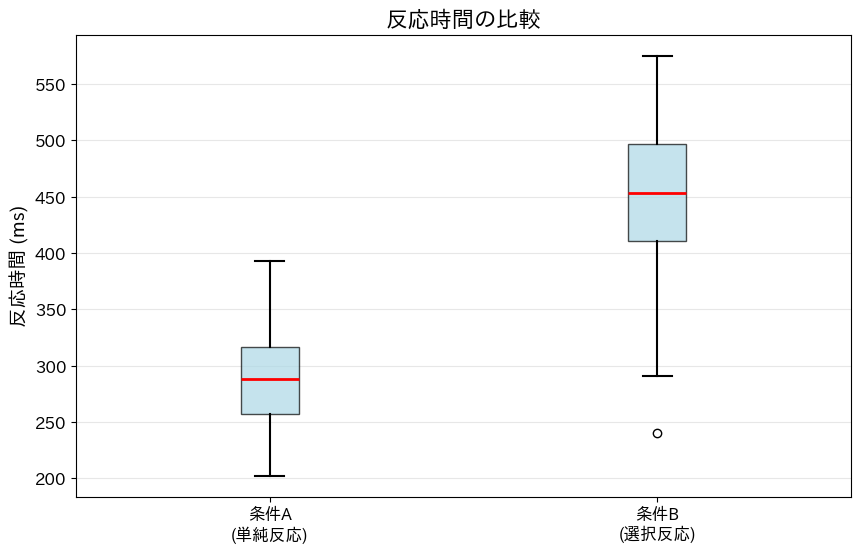

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

data_to_plot = [rt_condition_A, rt_condition_B]
labels = ['条件A\n(単純反応)', '条件B\n(選択反応)']

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='black', linewidth=1.5),
                capprops=dict(color='black', linewidth=1.5))

ax.set_ylabel('反応時間 (ms)', fontsize=14)
ax.set_title('反応時間の比較', fontsize=16, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.show()

## 6. 統計的検定（t検定）

2つの条件の平均値の差が統計的に有意かどうかを検定します。

In [6]:
# 独立したサンプルのt検定
t_stat, p_value = stats.ttest_ind(rt_condition_A, rt_condition_B)

print("=== t検定の結果 ===")
print(f"t値: {t_stat:.3f}")
print(f"p値: {p_value:.4f}")

if p_value < 0.05:
    print("\n結果: 有意差あり（p < 0.05）")
    print("→ 選択反応は単純反応よりも有意に遅い")
else:
    print("\n結果: 有意差なし（p >= 0.05）")

# 効果量（Cohen's d）の計算
pooled_std = np.sqrt(((len(rt_condition_A)-1)*np.var(rt_condition_A, ddof=1) +
                      (len(rt_condition_B)-1)*np.var(rt_condition_B, ddof=1)) /
                     (len(rt_condition_A) + len(rt_condition_B) - 2))
cohens_d = (np.mean(rt_condition_B) - np.mean(rt_condition_A)) / pooled_std

print(f"\n効果量（Cohen's d）: {cohens_d:.3f}")
print("（0.2: 小、0.5: 中、0.8: 大）")

=== t検定の結果 ===
t値: -13.680
p値: 0.0000

結果: 有意差あり（p < 0.05）
→ 選択反応は単純反応よりも有意に遅い

効果量（Cohen's d）: 2.736
（0.2: 小、0.5: 中、0.8: 大）


## 7. 考察：なぜ選択反応の方が遅いのか？

**入力→処理→出力の枠組みで考える**

### 条件A（単純反応）
1. **入力**: 刺激（○）の検出
2. **処理**: 刺激の認識のみ
3. **出力**: ボタン押し

### 条件B（選択反応）
1. **入力**: 刺激（○ or △）の検出
2. **処理**: 刺激の認識 + **刺激と反応の対応付け**（○→左、△→右）
3. **出力**: 適切なボタン押し

---

### 💡 重要な洞察

**追加された処理段階（対応付け）が、反応時間の遅延を生む**

このように、課題成績の差を「どの段階に何が追加されたか」という観点で説明できるのが、計算モデルのアプローチです。

## 8. 練習問題

以下のコードを修正して、**条件C（葛藤課題）**を追加してみましょう。

条件Cの設定：
- 平均RT: 550ms
- 標準偏差: 100ms

追加したデータを可視化し、条件A・Bと比較してみてください。

/tmp/ipykernel_2102/2268793126.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,


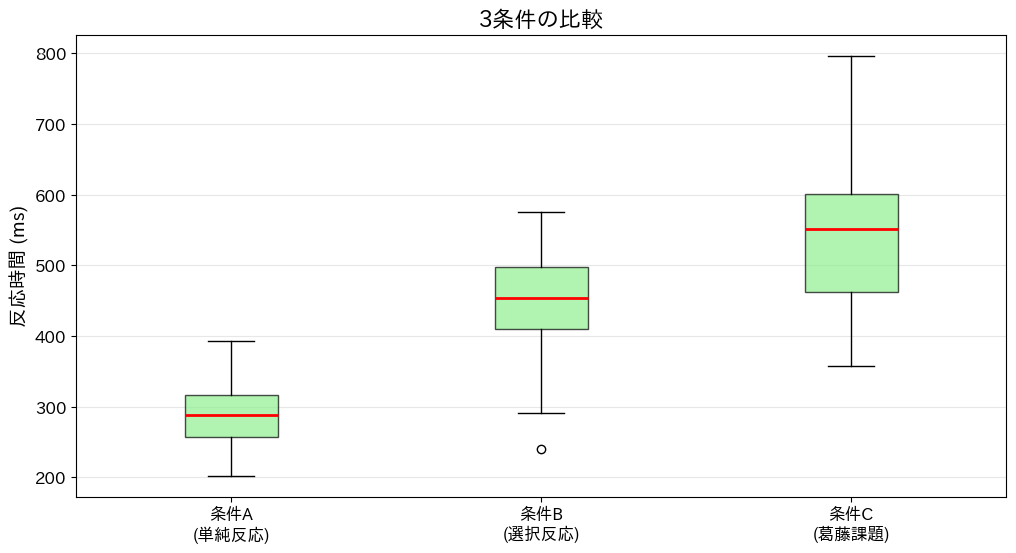

条件Cの平均RT: 546.07 ms
条件Cの標準偏差: 101.54 ms


In [7]:
# ここにコードを書いてください
# ヒント：上のセルのコードをコピーして、パラメータを変更

# 条件Cのデータ生成
mean_rt_C = 550
std_rt_C = 100
rt_condition_C = np.random.normal(mean_rt_C, std_rt_C, n_trials_A)
rt_condition_C = rt_condition_C[rt_condition_C > 0]

# 3条件の箱ひげ図
fig, ax = plt.subplots(figsize=(12, 6))
data_to_plot = [rt_condition_A, rt_condition_B, rt_condition_C]
labels = ['条件A\n(単純反応)', '条件B\n(選択反応)', '条件C\n(葛藤課題)']

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))

ax.set_ylabel('反応時間 (ms)', fontsize=14)
ax.set_title('3条件の比較', fontsize=16, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.show()

print(f"条件Cの平均RT: {np.mean(rt_condition_C):.2f} ms")
print(f"条件Cの標準偏差: {np.std(rt_condition_C, ddof=1):.2f} ms")

## 9. 発展課題（任意）

自分で条件を設定して、データを生成・可視化してみましょう。

例：
- **疲労の影響**: 試行が進むにつれてRTが増加
- **練習効果**: 試行が進むにつれてRTが減少
- **外れ値の影響**: 極端に遅い試行が混入

自由に試してみてください！

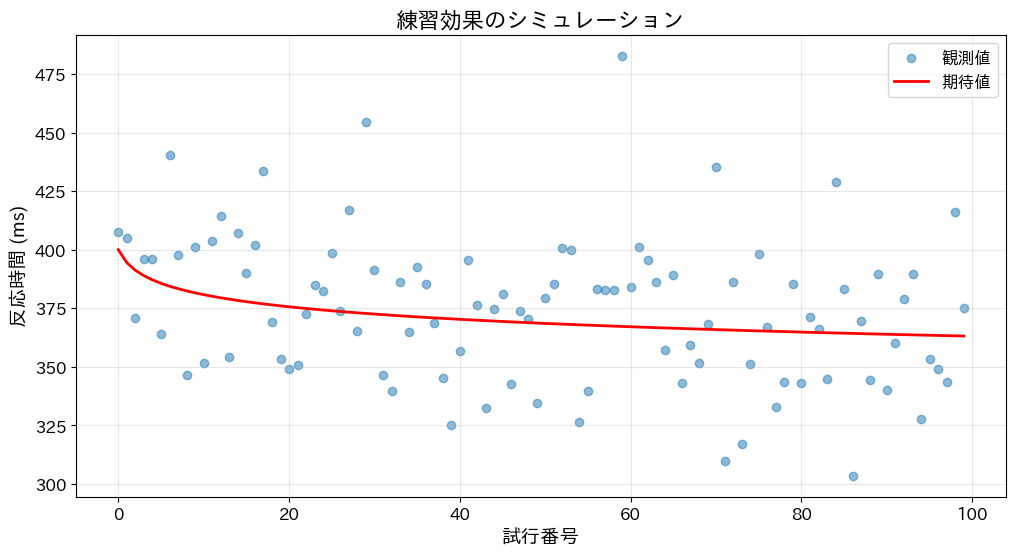

In [8]:
# 発展課題：ここに自由にコードを書いてください

# 例：練習効果のシミュレーション
n_trials = 100
baseline_rt = 400
learning_rate = 0.02  # 試行ごとに2%改善

# 各試行でのRTを計算
trial_numbers = np.arange(1, n_trials + 1)
expected_rt = baseline_rt * (1 - learning_rate * np.log(trial_numbers))
noise = np.random.normal(0, 30, n_trials)
observed_rt = expected_rt + noise
observed_rt = observed_rt[observed_rt > 0]  # 負の値を除去

# プロット
plt.figure(figsize=(12, 6))
plt.scatter(range(len(observed_rt)), observed_rt, alpha=0.5, label='観測値')
plt.plot(range(len(observed_rt)), expected_rt[:len(observed_rt)],
         color='red', linewidth=2, label='期待値')
plt.xlabel('試行番号', fontsize=14)
plt.ylabel('反応時間 (ms)', fontsize=14)
plt.title('練習効果のシミュレーション', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

## 10. まとめ

今日の実習で学んだこと：

1. **Google Colabの基本操作**: コードセルの実行、グラフの表示
2. **反応時間データの可視化**: ヒストグラム、箱ひげ図
3. **統計的検定**: t検定による条件間の比較
4. **入力→処理→出力**: 処理段階の違いがRT差を生む

---

### 次回予告

**第2回：行動指標の基礎**
- 平均とばらつきの意味
- 外れ値の検出と処理
- 誤反応の分類

---

**第1回実習は以上です。お疲れ様でした！**

質問があれば、授業後またはメールで受け付けます。